In [1]:
import os
import sys
sys.path.insert(0, "/home/thomasb/")

import numpy as np
import numba as nb
import time
import healpy as hp
import importlib
import matplotlib.pyplot as plt
from astropy.time import Time
import astropy.units as u
from astropy.coordinates import EarthLocation, SkyCoord, AltAz

from albatros_analysis.scripts.mapmaking import map_utils as mutils
from albatros_analysis.src.correlations import timing_solution_class as tsc

importlib.reload(tsc)
importlib.reload(mutils)

<module 'albatros_analysis.scripts.mapmaking.map_utils' from '/home/thomasb/albatros_analysis/scripts/mapmaking/map_utils.py'>

In [2]:
@nb.njit(parallel=True)
def geo_delay(bls, az, alt):
    npix = alt.shape[0]
    nbl = bls.shape[0] #each row is x, y, z
    print("nbl", nbl, "npix", npix)
    delays = np.empty((nbl,npix),dtype='float64')
    c=299792458
    for pix in nb.prange(npix):
        cos_alt = np.cos(np.pi * alt[pix] / 180)
        sin_alt = np.sin(np.pi * alt[pix] / 180)
        cos_az = np.cos(np.pi * az[pix] / 180)
        sin_az = np.sin(np.pi * az[pix] / 180)
        for bl in range(nbl):
            ea,no,up = bls[bl]
            p = 0
            p += sin_az*cos_alt * ea #east
            p += cos_az*cos_alt * no #north
            p += sin_alt * up #up
            delays[bl, pix] = p/c
    return delays

@nb.njit(parallel=True)
def get_map(data,freqs,delays,npix):
    print(data.shape, freqs.shape, delays.shape)
    map1 = np.zeros(npix, dtype=np.float64)
    nfreq, nbl = data.shape
    N_vis = nfreq * nbl
    for p in nb.prange(npix):
        pixel_sum = 0.
        for f in range(nfreq):
            nu = freqs[f]
            for b in range(nbl):
                tau = delays[p, b] #delay shape is npix, nbl for CPU

                # Calculate the fringe factor for this specific visibility
                fringe = np.exp(2j * np.pi * nu * tau)
                
                # Accumulate the dot product
                pixel_sum += fringe.real * data[f, b].real - fringe.imag * data[f, b].imag
        
        # Calculate the mean and assign to the pixel map
        map1[p] = pixel_sum / N_vis
    return map1

In [3]:
# load in data
with np.load('/home/mohanagr/Jupyter/MARS Fringe analysis (Summer 2025)/vis_dump.npz') as f:
    vis=f['vis']
    cnt=f['cnt']
    tstart=f['tstart']
    deltat=f['deltat']
    deltaf=f['deltaf']

In [4]:
ntimes, nfreq, nbl = vis.shape
print('ntimes', ntimes)
print('nfreq', nfreq)
print('nbl', nbl)

ntimes 10
nfreq 410
nbl 21


In [5]:
# setup
t_idx = 0
NSIDE = 1024

In [6]:
# get average visibility
vis_avg = np.mean(vis,axis=0)

In [7]:
# time stuff (center of visibility)
times_all = np.arange(tstart + deltat/2, tstart + ntimes*deltat + deltat/2, deltat)
print('start time', times_all[0])

# frequency stuff
fstart = 360*250e6/4096
freqs_all = np.arange(vis.shape[1]) * deltaf + fstart # in Hz
print('start freq', fstart)

#baseline stuff
nant=7
triu_idx=np.triu_indices(nant,k=1)
nbl = len(triu_idx[0])
print('nblines', nbl)

start time 1753264834.1802247
start freq 21972656.25
nblines 21


In [8]:
coords = {
        0: [79.417161473, -90.767238685, 187.9577], #MARS1
        1: [79.417198047, -90.758739192, 183.0684], #MARS2
        2: [79.388456412, -91.019202963, 25.1938],  #CSA
        3: [79.418302573, -90.667395452, 59.6242],  #MARS5
        4: [79.397984238, -90.799842408, 41.6994],  #MARS6
        5: [79.411474117, -90.695266129, 31.6314],  #MARS7
        6: [79.443757694, -90.718202634, 414.9131]  #MARS8
    }
antmap = {0:"MARS1", 1:"MARS2",2:"MARS4",3:"MARS5",4:"MARS6",5:"MARS7",6:"MARS8"}

In [9]:
# pixel count
NPIX=hp.nside2npix(NSIDE)
print(NPIX)

12582912


In [10]:
# pixel resolution
pix_res = hp.nside2resol(NSIDE,arcmin=True)
print(pix_res)

3.435486411817406


In [11]:
# create an array of RA/dec for NPIX pixels. just general array
co_dec, ra = hp.pix2ang(NSIDE,np.arange(NPIX))
dec = np.pi/2-co_dec

In [12]:
# set up ant0 as a location
ant0=EarthLocation.from_geodetic(lat=coords[0][0], lon=coords[0][1], height=coords[0][2])

In [13]:
# make observation time (first time index)
obstime0 = Time(times_all[t_idx],format="unix",scale="utc")
print(obstime0)
print(obstime0.unix)

1753264834.1802247
1753264834.1802247


In [14]:
# using ant0 positiona and observation time, get the observer-centric sky directions of each of the pixel coordinates
src = SkyCoord(ra=ra*u.rad, dec=dec*u.rad, frame='icrs')
pix_altaz =src.transform_to(AltAz(location=ant0,obstime=obstime0))

In [15]:
#baseline ENU distances for all blines
bl_enus_all = mutils.get_all_bls(coords, np.arange(len(coords)), enu=True)

#baseline ENU distances only for blines that contain the ref ant
bl_enus_ref =  mutils.get_all_bls(coords,np.arange(len(coords)), enu=True, refonly=True)

(21, 3)
(7, 3)


In [16]:
#delays for each baseline, for each pixel
delays_all = mutils.geo_delay_from_enu(bl_enus_all, pix_altaz.az.value, pix_altaz.alt.value)
print('delays_all shape', delays_all.shape)

#delays for each baseline with reference antenna in it
delays_ref = mutils.geo_delay_from_enu(bl_enus_ref, pix_altaz.az.value, pix_altaz.alt.value)
print('delays_ref shape', delays_ref.shape)

delays_all shape (21, 12582912)
delays_ref shape (7, 12582912)


In [17]:
#get clock delays
obj = tsc.TimingSolution(obstime0.unix, '/scratch/thomasb/timing_solution')
obstimes_unix, delays_clock = obj.interpolate_delay(obstime0.unix, obstime0.unix+10*deltat, deltat)
delays_clock_all, bline_names = obj.all_blines(delays_clock) #check the new functionality
delays_clock_all /= 1e9 #turn into ns

#get baselines associated with the clock delays
# ref_ant = obj.find_ref_ant(obstime0_unix, obstime0_unix + 10)
# other_ants = obj.find_other_ants(obstime0_unix, obstime0_unix + 10)

number of baselines (containing ref ant) in tau data: 6
number of desired interpolation unix times: 10
number of data unix times (1560,)


In [18]:
print(delays_clock[t_idx,:])
print(delays_clock_all[t_idx,:])

[-3012.81677746 -3012.81598866 -3012.74927151 -3012.67696861
 -3012.67140894 -3012.72095878 -3012.77460332 -3012.7718697
 -3012.71347877 -3012.71705553]
[-3.01281678e-06 -3.01281599e-06 -3.01274927e-06 -3.01267697e-06
 -3.01267141e-06 -3.01272096e-06 -3.01277460e-06 -3.01277187e-06
 -3.01271348e-06 -3.01271706e-06]


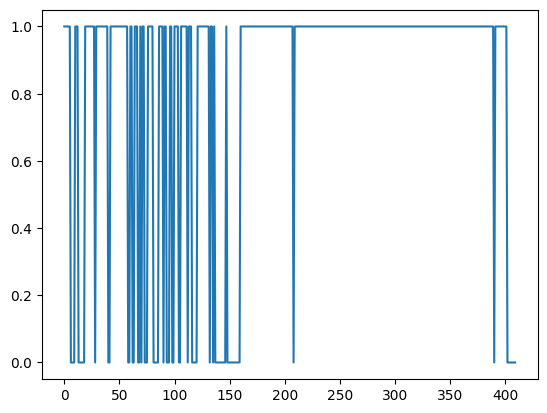

In [19]:
# RFI/corruption flagging
good_freq_idxs = np.bitwise_and.reduce(cnt[t_idx,:,1:]>0, axis=1)
plt.plot(good_freq_idxs)

In [20]:
# we exclude MARS1-MARS2 because too much RFI there
good_freqs = freqs_all[good_freq_idxs].copy()
delaysT = delays_all[1:, :].T.copy()
data = vis[t_idx, good_freq_idxs, 1:].copy()

In [21]:
print(np.isnan(data).any())
print(good_freqs.shape)
print(delaysT.shape)
print(data.shape)

False
(334,)
(12582912, 20)
(334, 20)


In [22]:
t1=time.time()
map1 = get_map(data, good_freqs, delaysT, NPIX)
t2=time.time()
print(t2-t1)

(334, 20) (334,) (12582912, 20)
358.27215099334717


In [23]:
print(map1)

[-0.02045526 -0.00188493 -0.00556864 ...  0.00399086  0.00611336
  0.01189816]


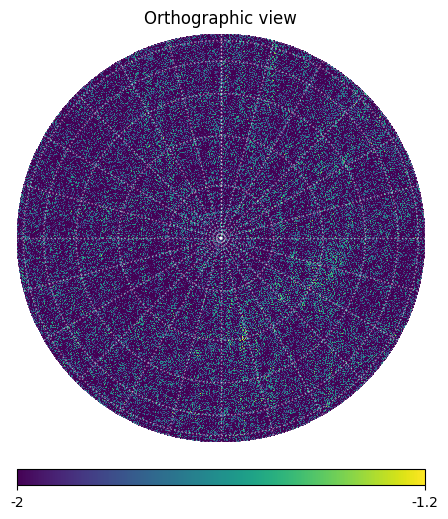

In [26]:
hp.orthview(np.log10(np.abs(map1)),min=-2,max=-1.2,rot=(0,90),half_sky=True,)
hp.graticule(dpar=15,  dmer=15, color='white', alpha=0.5, ls=':')

# hp.projscatter(src_vis[0].ra.deg, src_vis[0].dec.deg, lonlat=True, coord='C', 
#                marker='o',       # Circle marker
#                facecolors='none',# Hollow circle
#                edgecolors='red', # Red outline
#                s=100,            # Size of the circle
#           
#      lw=1,             # Line width
#                label='Cas A')

# hp.projscatter(src_vis[1].ra.deg, src_vis[1].dec.deg, lonlat=True, coord='C', 
#                marker='o',       # Circle marker
#                facecolors='none',# Hollow circle
#                edgecolors='magenta', # Red outline
#                s=100,            # Size of the circle
#                lw=1,             # Line width
#                label='Cyg A')


# plt.legend()
plt.show()

# Sim data

In [27]:
NSIDE = 256
NPIX=hp.nside2npix(NSIDE)
print("resol", hp.nside2resol(NSIDE,arcmin=True), "npix", NPIX)
co_dec,ra=hp.pix2ang(NSIDE,np.arange(NPIX))
dec=np.pi/2-co_dec

obstime=Time(tstart+t_idx*deltat+deltat/2,format="unix",scale="utc")
print(obstime)
src = SkyCoord(ra=ra*u.rad, dec=dec*u.rad, frame='icrs')
altaz =src.transform_to(AltAz(location=ant0,obstime=obstime))

ras = ['23h23m27.94s', '19h 59m 28.3566s']
decs = ['58d48m42.4s', "40° 44′ 02.096″"]
src_vis = SkyCoord(ra=ras,dec=decs , frame='icrs') 
altaz_vis = src_vis.transform_to(AltAz(location=ant0,obstime=obstime))

resol 13.741945647269624 npix 786432
1753264834.1802247


In [28]:
# source delays
delays_vis = mutils.geo_delay_from_enu(bl_enus_all, altaz_vis.az.value, altaz_vis.alt.value)
#pixel delays
delays = mutils.geo_delay_from_enu(bl_enus_all, altaz.az.value, altaz.alt.value)

In [29]:
# simulated data
freqs2 = np.arange(300) * deltaf + fstart #Hz
vis2 = 66 * np.exp(-2j*np.pi*delays_vis[:,0][None,:] * freqs2[:,None]) +\
      37 * np.exp(-2j*np.pi*delays_vis[:,1][None,:] * freqs2[:,None]) #casA 66,000 Jy, cyg A 37,000 Jy

In [30]:
data2 = vis2[:,:].copy()
delaysT2 = delays.T.copy()
good_freqs2 = freqs2[:].copy()

In [31]:
print(data2.shape)
print(delaysT2.shape)
print(good_freqs2.shape)

(300, 21)
(786432, 21)
(300,)


In [32]:
t1=time.time()
map2 = mutils.get_map(data2, good_freqs2, delaysT2, NPIX)
t2=time.time()
print(t2-t1)

(300, 21) (300,) (786432, 21)
19.99584412574768


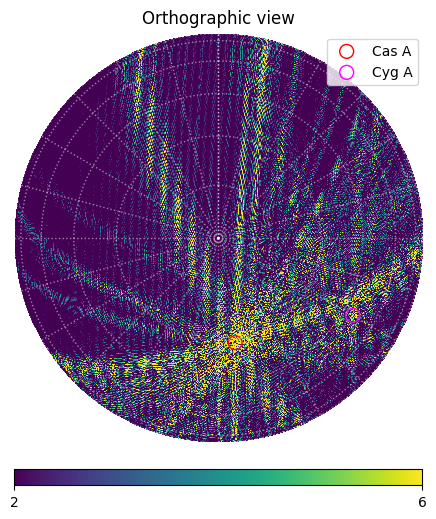

In [34]:
hp.orthview(np.abs(map2),
min=2,
max=6,
rot=(0,90),
half_sky=True)
hp.graticule(dpar=15,  dmer=15, color='white', alpha=0.5, ls=':')

cas_a = SkyCoord('23h23m27.94s', '58d48m42.4s', frame='icrs')
cyg_a = SkyCoord(ra='19h 59m 28.3566s', dec="40° 44′ 02.096″", frame='icrs') #Cyg A
hp.projscatter(cas_a.ra.deg, cas_a.dec.deg, lonlat=True, coord='C', 
               marker='o',       # Circle marker
               facecolors='none',# Hollow circle
               edgecolors='red', # Red outline
               s=100,            # Size of the circle
               lw=1,             # Line width
               label='Cas A')

hp.projscatter(cyg_a.ra.deg, cyg_a.dec.deg, lonlat=True, coord='C', 
               marker='o',       # Circle marker
               facecolors='none',# Hollow circle
               edgecolors='magenta', # Red outline
               s=100,            # Size of the circle
               lw=1,             # Line width
               label='Cyg A')

plt.legend()